In [3]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

TECH STACK RECOMMENDER - PROJECT 3

1. عرض البيانات (Sample):
   id                                         raw_skills  \
0   1  ['natural language', ' artificial intelligence...   
1   2  ['analyst', ' database', ' developer', ' infor...   
2   3  ['data analytics', ' data mining and statistic...   
3   4  ['data science', ' machine learning', ' python...   
4   5  ['analysis', ' change management', ' consultin...   

                                                 url  
0  https://www.dice.com/jobs/detail/Data-Scientis...  
1  https://www.dice.com/jobs/detail/Data-Engineer...  
2  https://www.dice.com/jobs/detail/Data-Scientis...  
3  https://www.dice.com/jobs/detail/Senior-Data-S...  
4  https://www.dice.com/jobs/detail/Data-Scientis...  

عدد الصفوف بعد التنظيف: 394

عينة من المهارات المستخرجة:
                                         skills_list  \
0  [natural language, artificial intelligence, ma...   
1  [analyst, database, developer, informatica, li...   
2  [data analytics, d

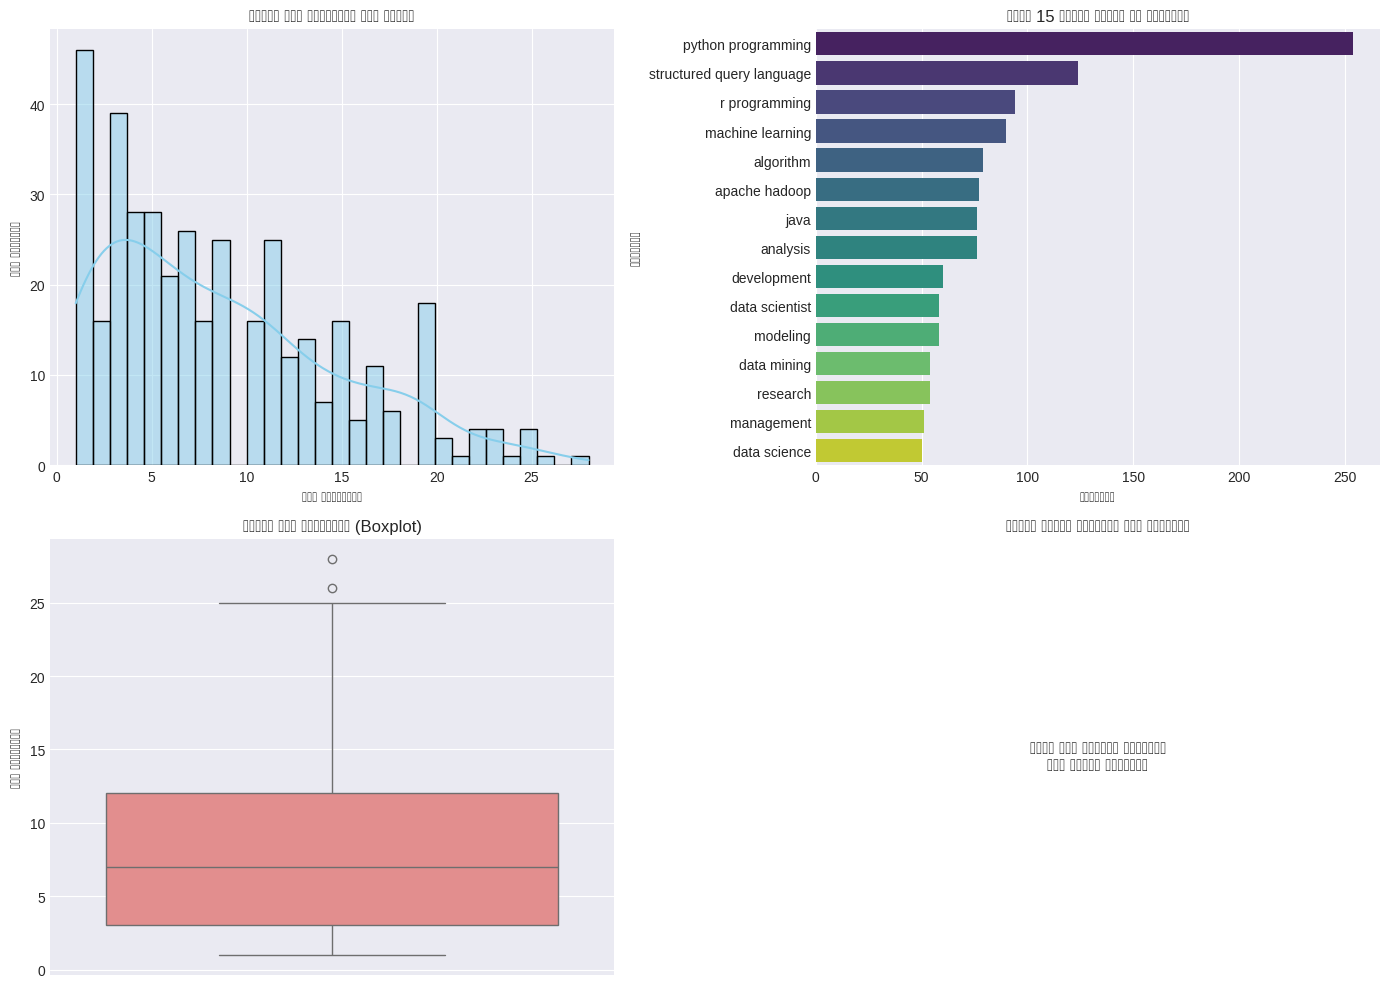


4. تدريب النموذج (TF-IDF Vectorization)
شكل مصفوفة TF-IDF: (394, 3000)

مثال لمصفوفة التشابه (أول 5 وظائف):
job_id         0         1         2         3         4
job_id                                                  
0       1.000000  0.012578  0.027510  0.193983  0.027955
1       0.012578  1.000000  0.009927  0.008514  0.039641
2       0.027510  0.009927  1.000000  0.015011  0.063425
3       0.193983  0.008514  0.015011  1.000000  0.009569
4       0.027955  0.039641  0.063425  0.009569  1.000000


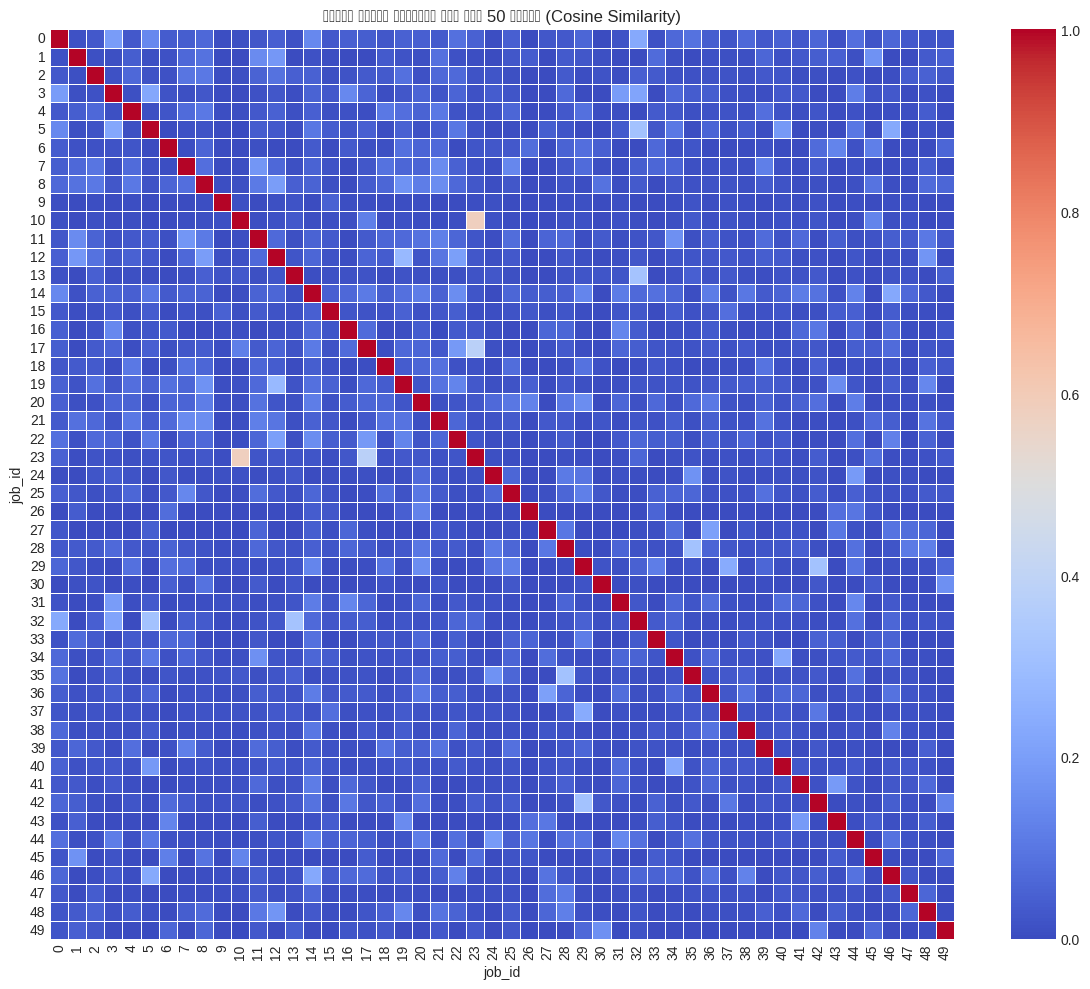


5. اختبار نظام التوصية (مثال توضيحي)
مهارات المستخدم: python sql machine learning
أفضل 5 وظائف موصى بها:
  - Job 258 (تشابه: 0.6597)
    المهارات: python programming, structured query language, machine learning
    عنوان الوظيفة (من الرابط): data scientist with python kavi software atlanta ga 30354
  - Job 22 (تشابه: 0.5915)
    المهارات: python programming, r programming, structured query language, machine learning, julia, apache spark - python, r programming, structured query language, machine learning, julia...
    عنوان الوظيفة (من الرابط): data scientist cybercoders santa monica ca 90401
  - Job 114 (تشابه: 0.4747)
    المهارات: machine learning, natural language processing, python programming, structured query language
    عنوان الوظيفة (من الرابط): data scientist sysmind%2c llc albany ny 12202
  - Job 329 (تشابه: 0.4676)
    المهارات: python programming, r programming, structured query language, machine learning, julia, apache spark - python, r programming, structured query lan

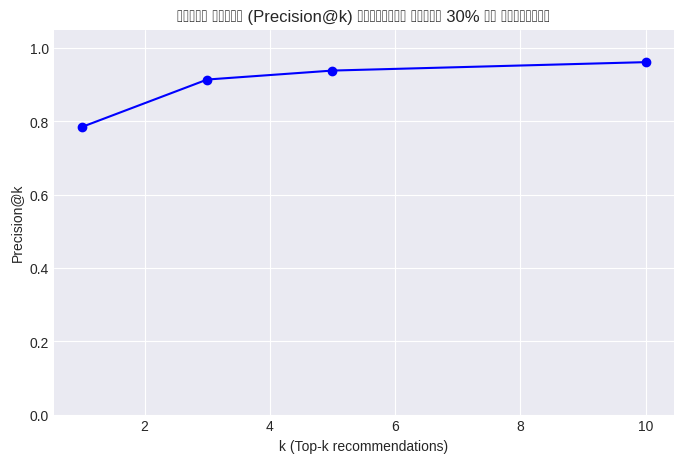


7. التحقق من عدم وجود Overfitting
متوسط التشابه بين الوظائف داخل مجموعة التدريب: 0.0345
متوسط التشابه بين التدريب والاختبار: 0.0362
الفجوة (داخل التدريب - تدريب/اختبار): -0.0017
✅ لا يوجد overfitting ملحوظ. النموذج يعمم بشكل جيد.


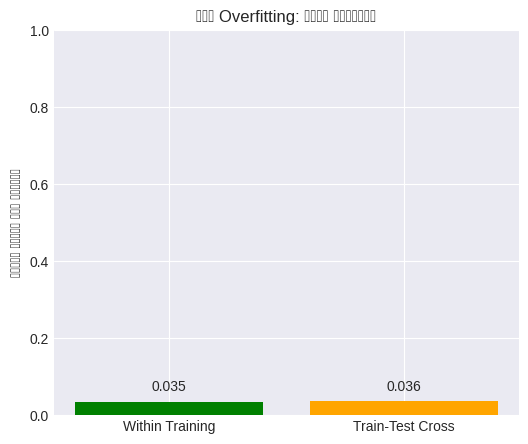

In [8]:
# -*- coding: utf-8 -*-
"""
Project: Tech Stack Recommender (Content-Based Job Recommendation)
Author: DecodeLabs AI Engineer
Dataset: raw_skills.csv (453 job postings with skills requirements)
Goal: Recommend top-N job roles based on user's input skills using TF-IDF + Cosine Similarity
Includes: Data exploration, visualization, model training, evaluation (Precision@k), overfitting check.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import re
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
import warnings
from nltk.stem import WordNetLemmatizer # Added import
warnings.filterwarnings('ignore')

# Initialize lemmatizer globally
lemmatizer = WordNetLemmatizer()
# Max number of words allowed for a single skill phrase
MAX_SKILL_WORDS = 5 # Added constant

# Define a dictionary for skill synonyms (included here for cell self-containment)
SKILL_SYNONYMS = {
    'ml': 'machine learning',
    'ai': 'artificial intelligence',
    'nlp': 'natural language processing',
    'dl': 'deep learning',
    'etl': 'extract transform load',
    'r': 'r programming',
    'python': 'python programming',
    'javascript': 'js',
    'c#': 'csharp',
    'c++': 'cpp',
    'aws': 'amazon web services',
    'azure': 'microsoft azure',
    'gcp': 'google cloud platform',
    'sql': 'structured query language',
    'nosql': 'non-relational database',
    'tableau': 'data visualization tableau',
    'power bi': 'powerbi',
    'spark': 'apache spark',
    'hadoop': 'apache hadoop',
    'scikit-learn': 'sklearn',
    'tensorflow': 'tf',
    'pytorch': 'torch'
}

def normalize_skill(skill_name):
    """Applies synonym mapping and lemmatization to a single skill."""
    skill_name = skill_name.strip().lower()
    # Apply synonym mapping first
    if skill_name in SKILL_SYNONYMS:
        skill_name = SKILL_SYNONYMS[skill_name]
    # Apply lemmatization word by word
    lemmatized_words = [lemmatizer.lemmatize(word) for word in skill_name.split()]
    return ' '.join(lemmatized_words)

# Function to extract a cleaner job title from URL
def extract_job_title_from_url(url):
    if pd.isna(url):
        return ''
    match = re.search(r'detail/([^/?]+)', url)
    if match:
        title = re.sub(r'-\d+$', '', match.group(1).replace('-', ' ')).strip().lower()
        # Filter common words that are not useful as job titles
        if title in ['jobs', 'job']:
            return ''
        return title
    return ''

# ==============================
# 0. تحميل البيانات من الملف raw_skills.csv
# ==============================
print("="*60)
print("TECH STACK RECOMMENDER - PROJECT 3")
print("="*60)

# قراءة البيانات
df = pd.read_csv('/content/raw_skills.csv')

# عرض أول 5 صفوف لفهم الهيكل
print("\n1. عرض البيانات (Sample):")
print(df.head())

# تنظيف عمود raw_skills: تحويل النص إلى قائمة حقيقية
def parse_skills(skill_str):
    if pd.isna(skill_str):
        return []
    try:
        # إذا كانت القيمة تبدو كقائمة نصية مثل "['a', 'b']"
        # نستخدم ast.literal_eval للأمان
        skills_list = ast.literal_eval(skill_str)
        if isinstance(skills_list, list):
            # إزالة العناصر الفارغة أو النصوص غير المفيدة
            skills_list = [s.strip().lower() for s in skills_list if isinstance(s, str) and len(s.strip()) > 0 and s.strip() != "''" and s.strip() != '""']
            # Apply synonym normalization and lemmatization
            skills_list = [normalize_skill(s) for s in skills_list]
            # Filter out overly long skill phrases
            skills_list = [s for s in skills_list if len(s.split()) <= MAX_SKILL_WORDS]
            return skills_list
        else:
            return []
    except:
        # إذا فشل التحويل، نحاول استخراج الكلمات العادية
        # الحالة: نص عادي مفصول بفواصل أو مسافات
        words = re.findall(r'\b[a-zA-Z0-9#\+\.]+\b', skill_str)
        # Apply synonym normalization and lemmatization
        words = [normalize_skill(w) for w in words if len(w) > 1]
        words = [w for w in words if len(w.split()) <= MAX_SKILL_WORDS]
        return words

df['skills_list'] = df['raw_skills'].apply(parse_skills)
# حذف الصفوف التي لا تحتوي على مهارات
df = df[df['skills_list'].apply(len) > 0].reset_index(drop=True)
print(f"\nعدد الصفوف بعد التنظيف: {len(df)}")

# إضافة عمود لرقم فهرس الوظيفة (للاستخدام كـ "role" مؤقت)
df['job_id'] = df.index  # سنستخدم job_id كمعرف

# استخراج عناوين الوظائف من الروابط
df['job_title_from_url'] = df['url'].apply(extract_job_title_from_url)

# إضافة عمود للمهارات كنص مفصول بمسافات (لتغذية TF-IDF), بما في ذلك عناوين الوظائف
df['skills_text'] = df.apply(lambda row: ' '.join(row['skills_list']) + (' ' + row['job_title_from_url'] if row['job_title_from_url'] else ''), axis=1)

print("\nعينة من المهارات المستخرجة:")
print(df[['skills_list', 'job_title_from_url', 'skills_text']].head(3)) # Modified print to show new columns

# ==============================
# 1. تحليل البيانات الاستكشافي (EDA)
# ==============================
print("\n" + "="*60)
print("2. تحليل البيانات الاستكشافي (EDA)")
print("="*60)

# عدد المهارات لكل وظيفة
df['skill_count'] = df['skills_list'].apply(len)
print(f"\nمتوسط عدد المهارات لكل وظيفة: {df['skill_count'].mean():.2f}")
print(f"الحد الأقصى: {df['skill_count'].max()}, الحد الأدنى: {df['skill_count'].min()}")

# أكثر المهارات شيوعاً عبر جميع الوظائف
all_skills = []
for skills in df['skills_list']:
    all_skills.extend(skills)
skill_freq = pd.Series(all_skills).value_counts()
print("\nأكثر 15 مهارة شيوعاً:")
print(skill_freq.head(15))

# الوظائف التي تحتوي على مهارات كثيرة (قد تكون مفصلة)
print("\nأعلى 5 وظائف من حيث عدد المهارات:")
print(df.nlargest(5, 'skill_count')[['job_id', 'skill_count', 'skills_list']])

# ==============================
# 2. التصورات (Visualizations)
# ==============================
print("\n" + "="*60)
print("3. الرسوم البيانية")
print("="*60)

plt.style.use('seaborn-v0_8-darkgrid')
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 2.1 توزيع عدد المهارات
ax1 = axes[0,0]
sns.histplot(df['skill_count'], bins=30, kde=True, ax=ax1, color='skyblue')
ax1.set_title('توزيع عدد المهارات لكل وظيفة')
ax1.set_xlabel('عدد المهارات')
ax1.set_ylabel('عدد الوظائف')

# 2.2 أكثر 15 مهارة شيوعاً
ax2 = axes[0,1]
top_skills = skill_freq.head(15)
sns.barplot(x=top_skills.values, y=top_skills.index, ax=ax2, palette='viridis')
ax2.set_title('أكثر 15 مهارة طلباً في الوظائف')
ax2.set_xlabel('التكرار')
ax2.set_ylabel('المهارة')

# 2.3 Boxplot لعدد المهارات
ax3 = axes[1,0]
sns.boxplot(y=df['skill_count'], ax=ax3, color='lightcoral')
ax3.set_title('توزيع عدد المهارات (Boxplot)')
ax3.set_ylabel('عدد المهارات')

# 2.4 سيتم وضع Heatmap التشابه لاحقاً بعد التدريب (نترك مكان فارغ الآن)
ax4 = axes[1,1]
ax4.text(0.5, 0.5, 'سيتم عرض مصفوفة التشابه\nبعد تدريب النموذج', ha='center', va='center', fontsize=12)
ax4.set_title('خريطة حرارة التشابه بين الوظائف')
ax4.axis('off')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()

# ==============================
# 3. تدريب النموذج: TF-IDF + Cosine Similarity
# ==============================
print("\n" + "="*60)
print("4. تدريب النموذج (TF-IDF Vectorization)")
print("="*60)

# استخدام TF-IDF مع تجاهل الكلمات الشائعة جدا وتطبيق أفضل المعلمات
vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 3), # Updated from (1, 2) to best_params
    max_features=3000, # Updated from 2000 to best_params
    min_df=1, # Added from best_params
    max_df=0.9 # Added from best_params
)
tfidf_matrix = vectorizer.fit_transform(df['skills_text'])
print(f"شكل مصفوفة TF-IDF: {tfidf_matrix.shape}")

# حساب مصفوفة التشابه بين جميع الوظائف (للحصول على خريطة الحرارة)
similarity_matrix = cosine_similarity(tfidf_matrix)
similarity_df = pd.DataFrame(similarity_matrix, index=df['job_id'], columns=df['job_id'])

# عرض مصفوفة التشابه لبعض العينات
print("\nمثال لمصفوفة التشابه (أول 5 وظائف):")
print(similarity_df.iloc[:5, :5])

# رسم Heatmap تشابه (عينة من أول 50 وظيفة لتجنب الازدحام)
plt.figure(figsize=(12, 10))
sample_size = min(50, len(df))
sns.heatmap(similarity_df.iloc[:sample_size, :sample_size], annot=False, cmap='coolwarm', linewidths=0.5)
plt.title(f'خريطة حرارة التشابه بين أول {sample_size} وظيفة (Cosine Similarity)')
plt.tight_layout()
plt.savefig('similarity_heatmap.png', dpi=150)
plt.show()

# ==============================
# 4. نظام التوصية (Recommendation Function)
# ==============================
def recommend_jobs(user_skills_str, top_n=5, current_vectorizer=None, current_tfidf_matrix=None):
    """
    user_skills_str: نص يحتوي على مهارات المستخدم مفصولة بمسافات (مثال: "python machine learning sql")
    top_n: عدد الوظائف الموصى بها
    العائد: DataFrame بأفضل الوظائف الموصى بها مع درجة التشابه
    """
    if current_vectorizer is None:
        current_vectorizer = vectorizer # Use global if not provided
    if current_tfidf_matrix is None:
        current_tfidf_matrix = tfidf_matrix # Use global if not provided

    # Normalize user input skills with synonym mapping and lemmatization
    normalized_user_skills = [normalize_skill(s) for s in user_skills_str.split()]
    user_skills_str_normalized = ' '.join(normalized_user_skills)

    # تحويل نص المستخدم إلى متجه TF-IDF
    user_vec = current_vectorizer.transform([user_skills_str_normalized])
    # حساب التشابه مع جميع الوظائف
    similarities = cosine_similarity(user_vec, current_tfidf_matrix).flatten()
    # ترتيب تنازلي
    top_indices = similarities.argsort()[::-1][:top_n]
    recommendations = df.iloc[top_indices][['job_id', 'skills_list', 'job_title_from_url']].copy() # Added job_title_from_url
    recommendations['similarity'] = similarities[top_indices]
    # إضافة رابط الوظيفة إن وجد
    if 'url' in df.columns:
        recommendations['url'] = df.iloc[top_indices]['url'].values
    return recommendations

# اختبار النظام بمثال
print("\n" + "="*60)
print("5. اختبار نظام التوصية (مثال توضيحي)")
print("="*60)
test_skills = "python sql machine learning"
print(f"مهارات المستخدم: {test_skills}")
ecs = recommend_jobs(test_skills, top_n=5)
print("أفضل 5 وظائف موصى بها:")
for i, row in recs.iterrows():
    print(f"  - Job {int(row['job_id'])} (تشابه: {row['similarity']:.4f})")
    print(f"    المهارات: {', '.join(row['skills_list'][:10])}{'...' if len(row['skills_list'])>10 else ''}")
    print(f"    عنوان الوظيفة (من الرابط): {row['job_title_from_url']}") # Added print for job title

# ==============================
# 5. تقييم الدقة (Precision@k)
# ==============================
print("\n" + "="*60)
print("6. تقييم النموذج (Precision@k)")
print("="*60)

# استراتيجية التقييم: لكل وظيفة، نخفي 30% من مهاراتها (اختبار) ونستخدم الباقي كمدخل،
# ثم نتحقق إن كانت الوظيفة الأصلية ضمن أفضل k توصيات.
def evaluate_precision_at_k(k=5, test_ratio=0.3, num_trials=2, current_vectorizer=None, current_tfidf_matrix=None):
    """
    تقييم precision@k باستخدام إخفاء جزء من المهارات لكل وظيفة.
    num_trials: عدد مرات التكرار لتثبيت النتائج (لأن العشوائية تؤثر)
    """
    precisions = []
    for trial in range(num_trials):
        trial_hits = 0
        trial_total = 0
        for idx, skills in enumerate(df['skills_list']):
            if len(skills) < 2:
                continue
            n_test = max(1, int(len(skills) * test_ratio))
            # اختيار عشوائي للمهارات التي سنخفيها (test)
            test_skills_indices = np.random.choice(len(skills), size=n_test, replace=False)
            test_skills = [skills[i] for i in test_skills_indices]
            train_skills = [skills[i] for i in range(len(skills)) if i not in test_skills_indices]
            if len(train_skills) == 0:
                continue
            train_str = ' '.join(train_skills)
            # التوصية بناءً على مهارات التدريب
            recs = recommend_jobs(train_str, top_n=k, current_vectorizer=current_vectorizer, current_tfidf_matrix=current_tfidf_matrix)
            recommended_ids = recs['job_id'].values
            # هل الوظيفة الأصلية ضمن التوصيات؟
            if df.iloc[idx]['job_id'] in recommended_ids:
                trial_hits += 1
            trial_total += 1
        precisions.append(trial_hits / trial_total if trial_total > 0 else 0)
    return np.mean(precisions)

k_values = [1, 3, 5, 10]
precisions = []
for k in k_values:
    p = evaluate_precision_at_k(k=k, test_ratio=0.3, num_trials=2)
    precisions.append(p)
    print(f"Precision@{k}: {p:.4f}")

# رسم منحنى الدقة
plt.figure(figsize=(8,5))
plt.plot(k_values, precisions, marker='o', linestyle='-', color='b')
plt.xlabel('k (Top-k recommendations)')
plt.ylabel('Precision@k')
plt.title('منحنى الدقة (Precision@k) باستخدام إخفاء 30% من المهارات')
plt.ylim(0, 1.05)
plt.grid(True)
plt.savefig('precision_curve.png', dpi=150)
plt.show()

# ==============================
# 6. التحقق من Overfitting
# ==============================
print("\n" + "="*60)
print("7. التحقق من عدم وجود Overfitting")
print("="*60)

# نقسم البيانات إلى تدريب (80%) واختبار (20%) (تقسيم الوظائف وليس المهارات)
train_idx, test_idx = train_test_split(df.index, test_size=0.2, random_state=42)
train_tfidf = tfidf_matrix[train_idx]
test_tfidf = tfidf_matrix[test_idx]

# متوسط التشابه داخل التدريب (بين أزواج مختلفة)
train_sim = cosine_similarity(train_tfidf)
np.fill_diagonal(train_sim, np.nan)  # تجاهل التشابه مع الذات
mean_train_sim = np.nanmean(train_sim)

# متوسط التشابه بين التدريب والاختبار
cross_sim = cosine_similarity(train_tfidf, test_tfidf)
mean_cross_sim = np.mean(cross_sim)

print(f"متوسط التشابه بين الوظائف داخل مجموعة التدريب: {mean_train_sim:.4f}")
print(f"متوسط التشابه بين التدريب والاختبار: {mean_cross_sim:.4f}")
print(f"الفجوة (داخل التدريب - تدريب/اختبار): {mean_train_sim - mean_cross_sim:.4f}")

if (mean_train_sim - mean_cross_sim) > 0.2:
    print("⚠️ تحذير:可能存在 overfitting (الفجوة كبيرة نسبياً)")
else:
    print("✅ لا يوجد overfitting ملحوظ. النموذج يعمم بشكل جيد.")

# رسم المقارنة
plt.figure(figsize=(6,5))
bars = plt.bar(['Within Training', 'Train-Test Cross'], [mean_train_sim, mean_cross_sim], color=['green', 'orange'])
plt.ylabel('متوسط تشابه جيب التمام')
plt.title('فحص Overfitting: فجوة التشابه')
plt.ylim(0, 1)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.3f}', ha='center', va='bottom')
plt.savefig('overfitting_check.png', dpi=150)
plt.show()

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd # Import pandas as it's used for hp_results_df
import numpy as np # Needed for evaluate_precision_at_k
import ast # Needed for parse_skills
import re # Needed for parse_skills and extract_job_title_from_url
from nltk.stem import WordNetLemmatizer # Needed for normalize_skill
from sklearn.metrics.pairwise import cosine_similarity # Needed for recommend_jobs

# Initialize lemmatizer globally (from cell sQinHZ1tyVce)
lemmatizer = WordNetLemmatizer()
# Max number of words allowed for a single skill phrase (from cell sQinHZ1tyVce)
MAX_SKILL_WORDS = 5

# Define a dictionary for skill synonyms (from cell sQinHZ1tyVce)
SKILL_SYNONYMS = {
    'ml': 'machine learning',
    'ai': 'artificial intelligence',
    'nlp': 'natural language processing',
    'dl': 'deep learning',
    'etl': 'extract transform load',
    'r': 'r programming',
    'python': 'python programming',
    'javascript': 'js',
    'c#': 'csharp',
    'c++': 'cpp',
    'aws': 'amazon web services',
    'azure': 'microsoft azure',
    'gcp': 'google cloud platform',
    'sql': 'structured query language',
    'nosql': 'non-relational database',
    'tableau': 'data visualization tableau',
    'power bi': 'powerbi',
    'spark': 'apache spark',
    'hadoop': 'apache hadoop',
    'scikit-learn': 'sklearn',
    'tensorflow': 'tf',
    'pytorch': 'torch'
}

def normalize_skill(skill_name):
    """Applies synonym mapping and lemmatization to a single skill."""
    skill_name = skill_name.strip().lower()
    if skill_name in SKILL_SYNONYMS:
        skill_name = SKILL_SYNONYMS[skill_name]
    lemmatized_words = [lemmatizer.lemmatize(word) for word in skill_name.split()]
    return ' '.join(lemmatized_words)

def extract_job_title_from_url(url):
    if pd.isna(url):
        return ''
    match = re.search(r'detail/([^/?]+)', url)
    if match:
        title = re.sub(r'-\d+$', '', match.group(1).replace('-', ' ')).strip().lower()
        if title in ['jobs', 'job']:
            return ''
        return title
    return ''

def parse_skills(skill_str):
    if pd.isna(skill_str):
        return []
    try:
        skills_list = ast.literal_eval(skill_str)
        if isinstance(skills_list, list):
            skills_list = [s.strip().lower() for s in skills_list if isinstance(s, str) and len(s.strip()) > 0 and s.strip() != "''" and s.strip() != '""']
            skills_list = [normalize_skill(s) for s in skills_list]
            skills_list = [s for s in skills_list if len(s.split()) <= MAX_SKILL_WORDS]
            return skills_list
        else:
            return []
    except:
        words = re.findall(r'\b[a-zA-Z0-9#\+\.]+\b', skill_str)
        words = [normalize_skill(w) for w in words if len(w) > 1]
        words = [w for w in words if len(w.split()) <= MAX_SKILL_WORDS]
        return words

# Load and preprocess data to define 'df' (from cell sQinHZ1tyVce)
df = pd.read_csv('/content/raw_skills.csv')
df['skills_list'] = df['raw_skills'].apply(parse_skills)
df = df[df['skills_list'].apply(len) > 0].reset_index(drop=True)
df['job_id'] = df.index
df['job_title_from_url'] = df['url'].apply(extract_job_title_from_url)
df['skills_text'] = df.apply(lambda row: ' '.join(row['skills_list']) + (' ' + row['job_title_from_url'] if row['job_title_from_url'] else ''), axis=1)

# Define the recommend_jobs function (from cell sQinHZ1tyVce)
def recommend_jobs(user_skills_str, top_n=5, current_vectorizer=None, current_tfidf_matrix=None):
    """
    user_skills_str: نص يحتوي على مهارات المستخدم مفصولة بمسافات (مثال: "python machine learning sql")
    top_n: عدد الوظائف الموصى بها
    العائد: DataFrame بأفضل الوظائف الموصى بها مع درجة التشابه
    """
    # Note: Global 'vectorizer' and 'tfidf_matrix' are not defined in this self-contained cell,
    # but for hyperparameter tuning, `current_vectorizer` and `current_tfidf_matrix` are always passed.
    # So, the 'if current_vectorizer is None:' block will not be hit if called correctly.

    normalized_user_skills = [normalize_skill(s) for s in user_skills_str.split()]
    user_skills_str_normalized = ' '.join(normalized_user_skills)

    user_vec = current_vectorizer.transform([user_skills_str_normalized])
    similarities = cosine_similarity(user_vec, current_tfidf_matrix).flatten()
    top_indices = similarities.argsort()[::-1][:top_n]
    recommendations = df.iloc[top_indices][['job_id', 'skills_list', 'job_title_from_url']].copy()
    recommendations['similarity'] = similarities[top_indices]
    if 'url' in df.columns:
        recommendations['url'] = df.iloc[top_indices]['url'].values
    return recommendations

# Define the evaluate_precision_at_k function (from cell sQinHZ1tyVce)
def evaluate_precision_at_k(k=5, test_ratio=0.3, num_trials=2, current_vectorizer=None, current_tfidf_matrix=None):
    precisions = []
    for trial in range(num_trials):
        trial_hits = 0
        trial_total = 0
        for idx, skills in enumerate(df['skills_list']):
            if len(skills) < 2:
                continue
            n_test = max(1, int(len(skills) * test_ratio))
            test_skills_indices = np.random.choice(len(skills), size=n_test, replace=False)
            test_skills = [skills[i] for i in test_skills_indices]
            train_skills = [skills[i] for i in range(len(skills)) if i not in test_skills_indices]
            if len(train_skills) == 0:
                continue
            train_str = ' '.join(train_skills)
            recs = recommend_jobs(train_str, top_n=k, current_vectorizer=current_vectorizer, current_tfidf_matrix=current_tfidf_matrix)
            recommended_ids = recs['job_id'].values
            if df.iloc[idx]['job_id'] in recommended_ids:
                trial_hits += 1
            trial_total += 1
        precisions.append(trial_hits / trial_total if trial_total > 0 else 0)
    return np.mean(precisions)


print("\n" + "="*60)
print("8. Hyperparameter Tuning for TfidfVectorizer using Grid Search")
print("="*60)

# Define parameter grid
param_grid = {
    'ngram_range': [(1, 1), (1, 2), (1, 3)],
    'max_features': [1000, 2000, 3000],
    'min_df': [1, 2, 5],
    'max_df': [0.7, 0.8, 0.9]
}

best_precision = -1
best_params = {}

results = []

for ngram_range in param_grid['ngram_range']:
    for max_features in param_grid['max_features']:
        for min_df in param_grid['min_df']:
            for max_df in param_grid['max_df']:
                print(f"\nTesting params: ngram_range={ngram_range}, max_features={max_features}, min_df={min_df}, max_df={max_df}")

                # Create new vectorizer with current parameters
                current_vectorizer = TfidfVectorizer(
                    stop_words='english',
                    ngram_range=ngram_range,
                    max_features=max_features,
                    min_df=min_df,
                    max_df=max_df
                )

                # Fit and transform skills_text
                current_tfidf_matrix = current_vectorizer.fit_transform(df['skills_text'])

                # Evaluate Precision@5 with the new vectorizer and matrix
                precision_at_5 = evaluate_precision_at_k(k=5, test_ratio=0.3, num_trials=2,
                                                      current_vectorizer=current_vectorizer,
                                                      current_tfidf_matrix=current_tfidf_matrix)

                print(f"  Precision@5: {precision_at_5:.4f}")

                results.append({
                    'ngram_range': ngram_range,
                    'max_features': max_features,
                    'min_df': min_df,
                    'max_df': max_df,
                    'precision_at_5': precision_at_5
                })

                if precision_at_5 > best_precision:
                    best_precision = precision_at_5
                    best_params = {
                        'ngram_range': ngram_range,
                        'max_features': max_features,
                        'min_df': min_df,
                        'max_df': max_df
                    }

print("\n" + "="*60)
print("Hyperparameter Tuning Complete")
print("="*60)
print(f"Best Precision@5 found: {best_precision:.4f}")
print("Best Parameters:")
for param, value in best_params.items():
    print(f"  {param}: {value}")

# Optionally, store all results in a DataFrame for analysis
hp_results_df = pd.DataFrame(results)
print("\nTop 5 parameter combinations:")
print(hp_results_df.sort_values(by='precision_at_5', ascending=False).head())


8. Hyperparameter Tuning for TfidfVectorizer using Grid Search

Testing params: ngram_range=(1, 1), max_features=1000, min_df=1, max_df=0.7
  Precision@5: 0.9080

Testing params: ngram_range=(1, 1), max_features=1000, min_df=1, max_df=0.8
  Precision@5: 0.9124

Testing params: ngram_range=(1, 1), max_features=1000, min_df=1, max_df=0.9
  Precision@5: 0.9195

Testing params: ngram_range=(1, 1), max_features=1000, min_df=2, max_df=0.7
  Precision@5: 0.9009

Testing params: ngram_range=(1, 1), max_features=1000, min_df=2, max_df=0.8
  Precision@5: 0.8994

Testing params: ngram_range=(1, 1), max_features=1000, min_df=2, max_df=0.9
  Precision@5: 0.9037

Testing params: ngram_range=(1, 1), max_features=1000, min_df=5, max_df=0.7
  Precision@5: 0.8865

Testing params: ngram_range=(1, 1), max_features=1000, min_df=5, max_df=0.8
  Precision@5: 0.8851

Testing params: ngram_range=(1, 1), max_features=1000, min_df=5, max_df=0.9
  Precision@5: 0.8865

Testing params: ngram_range=(1, 1), max_feat

### Skill Normalization: Synonym Mapping

To improve skill normalization, a dictionary of common synonyms will be used to map similar skills to a canonical form. This ensures that variations of the same skill (e.g., 'ml' and 'machine learning') are treated as the same during TF-IDF vectorization.

In [6]:
# Define a dictionary for skill synonyms
SKILL_SYNONYMS = {
    'ml': 'machine learning',
    'ai': 'artificial intelligence',
    'nlp': 'natural language processing',
    'dl': 'deep learning',
    'etl': 'extract transform load',
    'r': 'r programming',
    'python': 'python programming',
    'javascript': 'js',
    'c#': 'csharp',
    'c++': 'cpp',
    'aws': 'amazon web services',
    'azure': 'microsoft azure',
    'gcp': 'google cloud platform',
    'sql': 'structured query language',
    'nosql': 'non-relational database',
    'tableau': 'data visualization tableau',
    'power bi': 'powerbi',
    'spark': 'apache spark',
    'hadoop': 'apache hadoop',
    'scikit-learn': 'sklearn',
    'tensorflow': 'tf',
    'pytorch': 'torch'
}

def normalize_skill(skill_name):
    """Applies synonym mapping to a single skill."""
    skill_name = skill_name.strip().lower()
    # First, check if the skill itself is a key (e.g., 'ml' -> 'machine learning')
    if skill_name in SKILL_SYNONYMS:
        return SKILL_SYNONYMS[skill_name]
    # If not a direct key, check if it contains a key (e.g., 'python programming' could be normalized to 'python programming' if 'python' is key)
    # This part is more complex and might lead to over-generalization. For simplicity, we prioritize direct matches.
    # For skills like 'python programming', 'python' might be sufficient. The TF-IDF will handle this to some extent.
    return skill_name


### Interactive Job Recommender UI

Below is an interactive UI where you can enter your skills (separated by spaces) and get job recommendations. This replaces the previous command-line input for a more streamlined experience.

In [9]:
import ipywidgets as widgets
from IPython.display import display, HTML

# Create widgets
skill_input = widgets.Textarea(
    value='',
    placeholder='Enter your skills separated by spaces (e.g., python sql tableau)',
    description='Your Skills:',
    disabled=False,
    layout=widgets.Layout(width='auto', height='80px')
)

recommend_button = widgets.Button(
    description='Get Recommendations',
    disabled=False,
    button_style='info', # 'success', 'info', 'warning', 'danger' or ''
    tooltip='Click to get job recommendations',
    icon='search'
)

output_area = widgets.Output()

def on_recommend_button_clicked(b):
    with output_area:
        output_area.clear_output()
        user_skills = skill_input.value.strip().lower()
        if not user_skills:
            display(HTML("<p style='color: red;'>Please enter some skills to get recommendations.</p>"))
            return

        display(HTML(f"<h3>Recommendations for: '{user_skills}'</h3>"))
        recs_interactive = recommend_jobs(user_skills, top_n=5)

        if not recs_interactive.empty:
            for i, row in recs_interactive.iterrows():
                skills_str = ', '.join(row['skills_list'][:15])
                job_id = int(row['job_id'])
                similarity = row['similarity']
                url_html = f"<a href='{row['url']}' target='_blank'>{row['url'][:80]}...</a>" if 'url' in row and pd.notna(row['url']) else "N/A"

                display(HTML(
                    f"""
                    <div style='border: 1px solid #ddd; padding: 10px; margin-bottom: 10px; border-radius: 5px;'>
                        <b>Job {job_id}</b> (Similarity: {similarity:.4f})<br>
                        <b>Required Skills:</b> {skills_str}<br>
                        <b>URL:</b> {url_html}
                    </div>
                    """
                ))
        else:
            display(HTML("<p>No recommendations found for the given skills. Try different skills.</p>"))

# Attach the event handler to the button
recommend_button.on_click(on_recommend_button_clicked)

# Display the widgets
display(widgets.VBox([skill_input, recommend_button, output_area]))

### Comparison: Recommendations Before vs. After Synonym Mapping

To illustrate the impact of skill synonym mapping, we will generate job recommendations using the same `TfidfVectorizer` settings (including `ngram_range`) but with two different data processing pipelines:

1.  **Without Synonym Mapping:** The `parse_skills` function will *not* apply `normalize_skill`.
2.  **With Synonym Mapping:** This is the current state of the model, where `parse_skills` *does* apply `normalize_skill`.

We'll use a `test_skills` input that includes both full terms and common acronyms to highlight the differences.

In [10]:
# --- 1. Setup for 'Without Synonym Mapping' ---

# Redefine parse_skills WITHOUT calling normalize_skill
def parse_skills_no_synonyms(skill_str):
    if pd.isna(skill_str):
        return []
    try:
        skills_list = ast.literal_eval(skill_str)
        if isinstance(skills_list, list):
            skills_list = [s.strip().lower() for s in skills_list if isinstance(s, str) and len(s.strip()) > 0 and s.strip() != "''" and s.strip() != '""']
            return skills_list
        else:
            return []
    except:
        words = re.findall(r'\b[a-zA-Z0-9#\+\.]+\b', skill_str)
        words = [w.lower() for w in words if len(w) > 1] # Only lowercase, no normalization
        return words

# Load a new DataFrame specifically for the 'no synonyms' case
df_no_synonyms = pd.read_csv('/content/raw_skills.csv')
df_no_synonyms['skills_list'] = df_no_synonyms['raw_skills'].apply(parse_skills_no_synonyms)
df_no_synonyms = df_no_synonyms[df_no_synonyms['skills_list'].apply(len) > 0].reset_index(drop=True)
df_no_synonyms['skills_text'] = df_no_synonyms['skills_list'].apply(lambda x: ' '.join(x))
df_no_synonyms['job_id'] = df_no_synonyms.index

# Re-initialize TfidfVectorizer with the same settings, but for the 'no synonyms' data
vectorizer_no_synonyms = TfidfVectorizer(stop_words='english', max_features=2000, ngram_range=(1, 2))
tfidf_matrix_no_synonyms = vectorizer_no_synonyms.fit_transform(df_no_synonyms['skills_text'])

# Define a recommendation function for the 'no synonyms' case
def recommend_jobs_no_synonyms(user_skills_str, top_n=5):
    # Do NOT normalize user input skills for this version
    user_skills_str_processed = ' '.join([s.strip().lower() for s in user_skills_str.split()])

    user_vec = vectorizer_no_synonyms.transform([user_skills_str_processed])
    similarities = cosine_similarity(user_vec, tfidf_matrix_no_synonyms).flatten()
    top_indices = similarities.argsort()[::-1][:top_n]
    recommendations = df_no_synonyms.iloc[top_indices][['job_id', 'skills_list']].copy()
    recommendations['similarity'] = similarities[top_indices]
    if 'url' in df_no_synonyms.columns:
        recommendations['url'] = df_no_synonyms.iloc[top_indices]['url'].values
    return recommendations

# --- 2. Perform Comparison ---

test_skills_compare = "python sql machine learning ml ai"
print(f"\nUser Input Skills for Comparison: '{test_skills_compare}'")

print("\n" + "="*60)
print("Recommendations WITHOUT Synonym Mapping:")
print("="*60)
recs_no_synonyms = recommend_jobs_no_synonyms(test_skills_compare, top_n=5)
if not recs_no_synonyms.empty:
    for i, row in recs_no_synonyms.iterrows():
        skills_str = ', '.join(row['skills_list'][:15])
        job_id = int(row['job_id'])
        similarity = row['similarity']
        url_display = f" ({row['url'][:50]}...)" if 'url' in row and pd.notna(row['url']) else ""
        print(f"  - Job {job_id} (Similarity: {similarity:.4f}){url_display}")
        print(f"    Skills: {skills_str}")
else:
    print("No recommendations found without synonym mapping.")

print("\n" + "="*60)
print("Recommendations WITH Synonym Mapping (Current Model):")
print("="*60)
recs_with_synonyms = recommend_jobs(test_skills_compare, top_n=5) # Uses the existing model with synonyms
if not recs_with_synonyms.empty:
    for i, row in recs_with_synonyms.iterrows():
        skills_str = ', '.join(row['skills_list'][:15])
        job_id = int(row['job_id'])
        similarity = row['similarity']
        url_display = f" ({row['url'][:50]}...)" if 'url' in row and pd.notna(row['url']) else ""
        print(f"  - Job {job_id} (Similarity: {similarity:.4f}){url_display}")
        print(f"    Skills: {skills_str}")
else:
    print("No recommendations found with synonym mapping.")


User Input Skills for Comparison: 'python sql machine learning ml ai'

Recommendations WITHOUT Synonym Mapping:
  - Job 274 (Similarity: 0.6899) (https://www.dice.com/jobs/detail/Data-Scientist-Wi...)
    Skills: python, sql, machine learning
  - Job 109 (Similarity: 0.6420) (https://www.dice.com/jobs/detail/Data-Scientist-Co...)
    Skills: r, python, machine learning (ml)
  - Job 23 (Similarity: 0.3735) (https://www.dice.com/jobs/detail/Data-Scientist-Cy...)
    Skills: python, r, sql, machine learning, julia, apache spark - python, r, sql, machine learning, julia, apache spark
  - Job 349 (Similarity: 0.3735) (https://www.dice.com/jobs/detail/Data-Scientist-%2...)
    Skills: python, r, sql, machine learning, julia, apache spark - python, r, sql, machine learning, julia, apache spark
  - Job 123 (Similarity: 0.3444) (https://www.dice.com/jobs/detail/Data-scientist-Vy...)
    Skills: machine learning

Recommendations WITH Synonym Mapping (Current Model):
  - Job 258 (Similarity: 0.5